# Telecomunicaciones: identificar operadores ineficaces

_**Link de Informe Final**_

https://drive.google.com/file/d/13ylqJA9-EVsNVWmF6zqvk4qqfW0OI9Q3/view?usp=sharing

_**Link Dashboard**_

https://public.tableau.com/views/Anlisisdeeficienciadeoperadores-CallMeMaybe/Dashboard1?:language=es-ES&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

In [1]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import math as mt
import datetime as dt

In [2]:
# Cargar datos
telecom = pd.read_csv('/datasets/telecom_dataset_us.csv')
telecom_clients = pd.read_csv('/datasets/telecom_clients_us.csv')

## Procesamiento y limpieza de datos

#### Dataset telecom

In [3]:
# Observar la calidad de los datos 
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


Se puede observar que la columna 'operator_id' contiene valores ausentes, los cuales se analizarán para saber si es seguro eliminar aquellas filas. Aquí no se pueden sustituir los valores, debido a que lo que se estudiará será el comportamiento de cada operador.
De igual manera, la columna cambiará a tipo de datos int.

La columna 'internal' muestra valores ausentes, los cuales se eliminarán, esto porque la cantidad es mínima y no afectará el análisis de esta.

In [4]:
# Eliminar valores ausentes
telecom = telecom.dropna()

In [5]:
# Cambiar la columna 'operator_id' a tipo de datos 'int'
telecom['operator_id'] = telecom['operator_id'].astype('int')
# Cambiar la columna 'date' a tipo de datos 'datetime'
telecom['date'] = pd.to_datetime(telecom['date'])

In [6]:
# Comprobamos los cambios
telecom.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 45670 entries, 1 to 53900
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                                
---  ------               --------------  -----                                
 0   user_id              45670 non-null  int64                                
 1   date                 45670 non-null  datetime64[ns, pytz.FixedOffset(180)]
 2   direction            45670 non-null  object                               
 3   internal             45670 non-null  object                               
 4   operator_id          45670 non-null  int64                                
 5   is_missed_call       45670 non-null  bool                                 
 6   calls_count          45670 non-null  int64                                
 7   call_duration        45670 non-null  int64                                
 8   total_call_duration  45670 non-null  int64                                
dtypes: bool

In [7]:
# Averiguar si existen duplicados
print('Valores duplicados: ', telecom.duplicated().sum())

Valores duplicados:  4179


In [8]:
# Qué porcentaje representa el número de duplicados con el total de datos
duplicated = telecom[telecom.duplicated()]
print('Porcentaje de valores duplicados: ', format((len(duplicated) / len(telecom)), '.1%'))

Porcentaje de valores duplicados:  9.2%


Los valores duplicados representan una cantidad pequeña, por lo que su eliminación no representa un daño al análisis posterior.

In [9]:
# Eliminar valores duplicados
telecom = telecom.drop_duplicates()

##### Crear columna de tiempo de espera

In [10]:
telecom['waiting_time'] = telecom['total_call_duration'] - telecom['call_duration']
telecom.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time
1,166377,2019-08-05 00:00:00+03:00,out,True,880022,True,3,0,5,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020,True,1,0,1,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020,False,1,10,18,8
4,166377,2019-08-05 00:00:00+03:00,out,False,880022,True,3,0,25,25
5,166377,2019-08-05 00:00:00+03:00,out,False,880020,False,2,3,29,26


#### Dataset telecom_clients

In [11]:
telecom_clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


In [12]:
print('Duplicados: ', telecom_clients.duplicated().sum())

Duplicados:  0


No existen valores ausentes, ni duplicados. Es necsario cambiar 'date_start' a tipo fecha, por si se ocupa en el EDA.

In [13]:
# Cambiar a datos tipo 'datetime'
telecom_clients['date_start'] = pd.to_datetime(telecom_clients['date_start'])
telecom_clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      732 non-null    int64         
 1   tariff_plan  732 non-null    object        
 2   date_start   732 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 17.3+ KB


In [14]:
telecom_clients.sample(5)

,user_id,tariff_plan,date_start
289,167500,C,2019-09-18
96,168529,C,2019-10-29
68,166427,A,2019-08-02
213,168042,C,2019-10-10
608,166956,B,2019-08-26


## Análisis exploratorio de datos

#### Identificar qué operadores realizan llamadas entrantes y cuáles realizan tanto llamadas entrantes como salientes.

In [15]:
# Identificar llamadas out e in
telecom['direction'].value_counts()

out    28813
in     12678
Name: direction, dtype: int64

In [16]:
# Contar llamadas por operador y dirección 
count_calls = telecom.groupby('operator_id')['direction'].value_counts()
# Crear columna para in y out
count_calls_unstack = count_calls.unstack(fill_value=0)
# reemplazar valores NaN a 0
count_calls_unstack = count_calls_unstack.fillna(0)

In [17]:
# Clasificar operadores por el tipo de llamdas
def classify_operator(row):
    if row.get('in', 0) > 0 and row.get('out',0) > 0:
        return 'entrantes_y_salientes'
    elif row.get('in', 0) > 0 and row.get('out', 0) == 0:
        return 'solo_entrantes'
    elif row.get('in', 0) == 0 and row.get('out', 0) > 0:
        return 'solo_salientes'
    else:
        return 'sin_actividad'

In [18]:
# Aplicar la función a la tabla
count_calls_unstack['operator_type'] = count_calls_unstack.apply(classify_operator, axis=1)

In [19]:
# Ver cuantos operador hay en cada tipo
count_calls_unstack['operator_type'].value_counts()

entrantes_y_salientes    544
solo_salientes           338
solo_entrantes           210
Name: operator_type, dtype: int64

In [20]:
# Filtrar solo por 'entrantes_y_salientes' y 'solo_entrantes'
operators = count_calls_unstack[count_calls_unstack['operator_type']
    .isin(['entrantes_y_salientes', 'solo_entrantes'])].index

telecom_filtered = telecom[telecom['operator_id'].isin(operators)]

Para el análisis se consideraron únicamente los operadores que atienden llamadas entrantes, ya que los principales indicadores de ineficiencia, como llamadas perdidas y tiempos de espera, solo pueden evaluarse en este tipo de interacciones.

Por esta razón, los operadores que realizan exclusivamente llamadas salientes fueron excluidos del análisis, ya que su función no impacta directamente en la experiencia del cliente en llamadas entrantes.

#### Calcular la tasa de llamadas perdidas por operador.

In [21]:
# Filtrar Llamadas entrantes
in_calls = telecom_filtered[telecom_filtered['direction'] == 'in']

# Contar llamadas entrantes por operador
total_in_calls = (in_calls.groupby('operator_id')['calls_count'].sum())

# Contar llamadas entrantes perdidas por operador
miss_in_calls = (in_calls[in_calls['is_missed_call']]
    .groupby('operator_id')['calls_count'].sum())

# Calcular tasa
missed_rate = pd.concat([total_in_calls, miss_in_calls], 
                        axis=1, keys=['total_in_calls', 'miss_in_calls']).fillna(0)

missed_rate['missed_call_rate'] = (missed_rate['miss_in_calls'] / missed_rate['total_in_calls'])

# Mostrar los operadores con más llamadas entrantes perdidas
missed_rate.sort_values('missed_call_rate', ascending=False).head()

,total_in_calls,miss_in_calls,missed_call_rate
operator_id,,,
948756,1,1.0,1.000000
904344,4,3.0,0.750000
913886,2,1.0,0.500000
906392,18,7.0,0.388889
957922,3,1.0,0.333333


Con la tabla podemos observa ya a los operadores con la mayor tasa de llamdas entrantes perdidas, para una mejor visualización a continuación se presenta un boxplot, ya que con este es más fáciol identificar a simple vista a aquellos operadores. Además, se visualizarán los valores extremos (operadores con el peor comportamiento).

#### Boxplot de la tasa de llamadas perdidas por operador

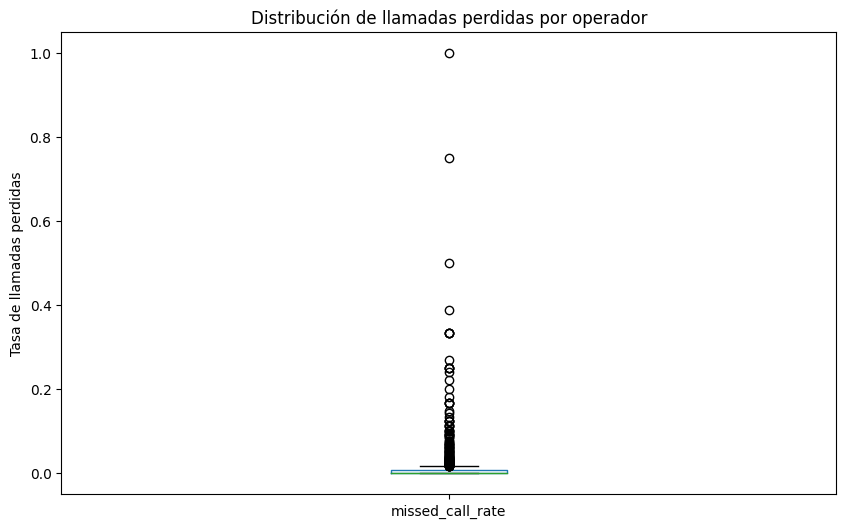

In [22]:
plt.figure(figsize=(10,6))
missed_rate['missed_call_rate'].plot(kind='box')
plt.title('Distribución de llamadas perdidas por operador')
plt.ylabel('Tasa de llamadas perdidas')
plt.show()

La mayoría de los operadores presenta tasas bajas de llamadas perdidas, sin embargo, se identifican valores atípicos con tasas considerablemente más altas, los cuales podrían indicar ineficiencia operativa.

Un histograma ayudará a establecer umbrales y definir a partir de que tasa se considera como operador ineficiente:

#### Histograma de la tasa de llamadas perdidas

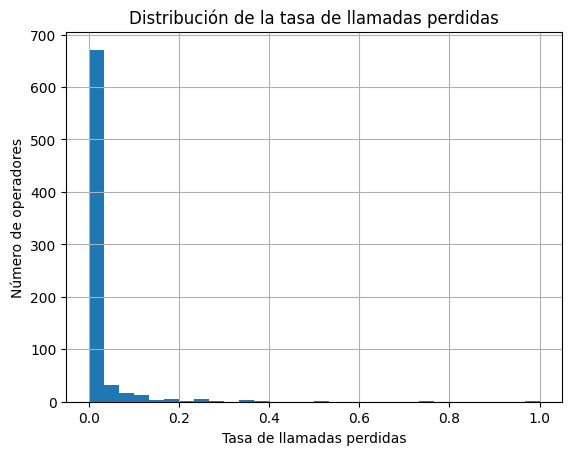

In [23]:
plt.figure()
missed_rate['missed_call_rate'].hist(bins=30)
plt.title('Distribución de la tasa de llamadas perdidas')
plt.xlabel('Tasa de llamadas perdidas')
plt.ylabel('Número de operadores')
plt.show()

In [24]:
# Calcular percentiles
p90 = np.percentile(missed_rate['missed_call_rate'], 90)
print('Percentil 90:', p90)
p95 = np.percentile(missed_rate['missed_call_rate'], 95)
print('Percentil 95:', p95)

Percentil 90: 0.037037037037037035
Percentil 95: 0.09142786561264825


In [25]:
# Operadores ineficientes
inefficient_ops = p90
print("Umbral de ineficiencia (operador > P90):", inefficient_ops)

inefficient_ops = missed_rate[missed_rate['missed_call_rate'] > inefficient_ops]
print("Número de operadores ineficientes:", inefficient_ops.shape[0])

inefficient_ops = p95
print("Umbral de ineficiencia (operador > P95):", inefficient_ops)

inefficient_ops = missed_rate[missed_rate['missed_call_rate'] > inefficient_ops]
print("Número de operadores ineficientes:", inefficient_ops.shape[0])

Umbral de ineficiencia (operador > P90): 0.037037037037037035
Número de operadores ineficientes: 75
Umbral de ineficiencia (operador > P95): 0.09142786561264825
Número de operadores ineficientes: 38


Se utilizó el percentiles 95 de la tasa de llamadas perdidas como umbral para identificar operadores realmente ineficientes. Aquellos operadores cuya tasa supera este valor presentan un desempeño considerablemente inferior al promedio del servicio.

Se recomienda tener en cuenta el percentil 90, pues con este se pueden identificar los operadores que potencialmente podrían llegar a convertirse en un problema, de esta manera se podría empezar a tomar acción con ellos y evitar mayor ineficiencia.

#### Calcular el tiempo promedio de espera por operador en llamadas entrantes.

In [26]:
# Filtrar solo por 'in' (lo volví a integrar en esta celda para evitar confusiones)
in_calls = telecom_filtered.loc[telecom_filtered['direction'] == 'in'].copy()

# Crear una variable para el tiempo de espera
in_calls['waiting_time'] = (in_calls['total_call_duration'] - in_calls['call_duration'])

# Evistar valores negativos
in_calls = in_calls[in_calls['waiting_time'] >= 0]

# Calcular el tiempo promedio de espera por operador
avg_waiting_time = in_calls.groupby('operator_id')['waiting_time'].mean().reset_index()
avg_waiting_time.rename(columns={'waiting_time': 'avg_waiting_time'},inplace=True)
avg_waiting_time.head()

,operator_id,avg_waiting_time
0,879896,27.333333
1,879898,29.875000
2,880020,7.714286
3,880022,14.000000
4,880026,7.944444


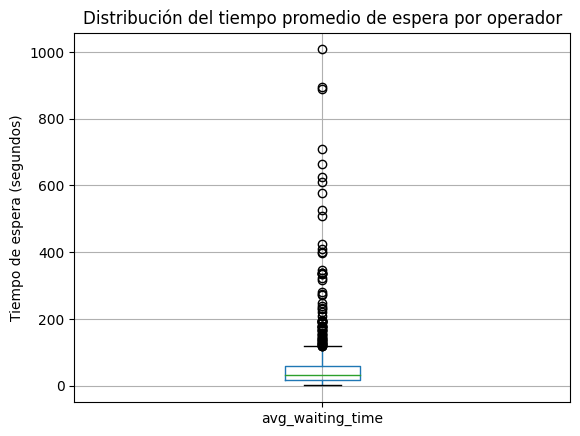

In [27]:
# Visualizar la tasa de tiempo de espera e identificar valores atípicos
plt.figure()
avg_waiting_time.boxplot(column='avg_waiting_time')
plt.title('Distribución del tiempo promedio de espera por operador')
plt.ylabel('Tiempo de espera (segundos)')
plt.show()

Los operadores con tiempos promedio de espera elevados presentan una mayor probabilidad de generar una experiencia negativa para los clientes, lo cual puede estar asociado a una gestión ineficiente de las llamadas entrantes.

In [28]:
# Calcular percentiles
p85 = np.percentile(avg_waiting_time['avg_waiting_time'], 85)
print('Percentil 85:', p85)

# Promedio de tiempo de espera
inefficient_wait = avg_waiting_time[avg_waiting_time['avg_waiting_time'] > p85]
print(inefficient_wait.head(10))

Percentil 85: 83.02499999999998
    operator_id  avg_waiting_time
9        882684        190.520000
10       882686        165.750000
11       882688        336.500000
12       882690        322.818182
21       885876        100.188889
22       885890        120.276596
26       887276        176.217391
53       891410        124.471429
54       891414        100.389831
68       892534        117.625000


Se utilizó el percentil 85 como umbral para identificar operadores con tiempos de espera inusualmente altos, concentrando el análisis en el 15% con peor desempeño.

#### Analizar el volumen de llamadas salientes por operador.

In [29]:
# Filtrar por operadores que realizan llamdas salientes
out_calls = telecom_filtered.loc[telecom_filtered['direction'] == 'out'].copy()

#Calcular vollumen de llamadas salientes por operador
out_calls_volume = out_calls.groupby('operator_id').size().reset_index(name='out_calls_count')

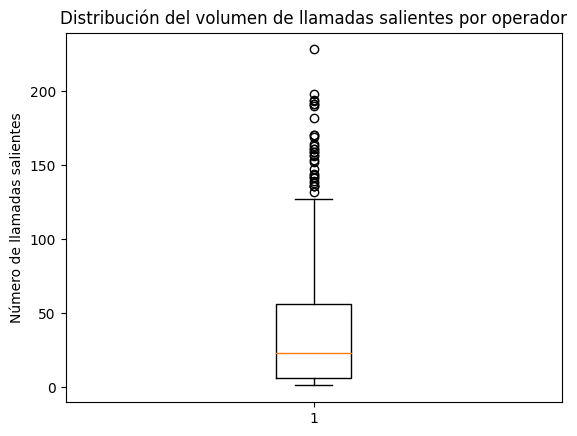

In [30]:
# Visualizar con un boxplot
plt.boxplot(out_calls_volume['out_calls_count'])
plt.title('Distribución del volumen de llamadas salientes por operador')
plt.ylabel('Número de llamadas salientes')
plt.show()

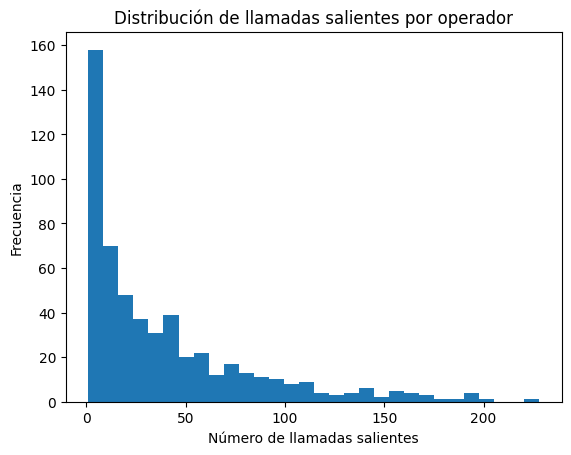

In [31]:
# Visualización con un histograma
plt.hist(out_calls_volume['out_calls_count'], bins=30)
plt.title('Distribución de llamadas salientes por operador')
plt.xlabel('Número de llamadas salientes')
plt.ylabel('Frecuencia')
plt.show()

Al observar ambos gráficos se puede ver que la distribución es asimétrica (sesgada a la derecha).
La mediana está relativamente baja (alrededor de 20–25 llamadas).La mayoría de los operadores hace pocas llamadas salientes, pero los demás operadores hacen muchísimas más llamadas que el promedio, algunos operadores llegan a más de 200 llamadas salientes.

In [32]:
# Identificar bajo desempeño
# Calcular percentiles
p25 = np.percentile(out_calls_volume['out_calls_count'], 25)
print('Percentil 25:', p25)

# Promedio de tiempo de espera
low_out_calls = out_calls_volume[out_calls_volume['out_calls_count'] < p25]
print(low_out_calls.head())

Percentil 25: 6.0
    operator_id  out_calls_count
6        882478                1
28       888538                5
33       890226                2
45       891744                4
47       891908                5


Con el percentil 25 obtenemos el 25% con menor volumen de llamadas. 

### Reglas finales para identificar a operadores ineficientes

La regla se va a definir con ayuda de los KPI's que ya se han calculado con anterioridad, utilizando los percentiles propuestos en cada uno, de esta manera, se identificará a los operadores ineficientes con mayor facilidad.

#### KPI 1: Tasa de llamadas perdidas

In [33]:
p90_missed_calls = np.percentile(missed_rate['missed_call_rate'], 90)

Un operador es ineficiente si su tasa de llamadas perdidas > P90

#### KPI 2: Tiempo promedio de espera

In [34]:
p85_waiting_time = np.percentile(avg_waiting_time['avg_waiting_time'], 85)

Un operador es ineficiente si su tasa de tiempo de espera promedio > P85 

#### KPI 3: Volumen de llamadas salientes

In [35]:
p25_out_calls = np.percentile(out_calls_volume['out_calls_count'], 25)

Un operador tiene bajo desempeño si el volumen de llamadas salientes < P25

**Operadores ineficientes:**

Un operador se considera ineficiente si cumple al menos una de las siguientes condiciones:
* Tiene una tasa de llamadas perdidas > P85
* Tiene un tiempo de espera promedio > P85
* Tiene un volumen de llamadas salientes < P25 (si aplica)

Para identificar los operadores ineficientes se crearán columnas boleanas (False y True) para poder filtrar rápidamente dependiendo del KPI que queramos estudiar.

In [36]:
# Crear columnas de KPI´s
missed_rate['high_missed_calls'] = missed_rate['missed_call_rate' ] > p90_missed_calls

In [37]:
avg_waiting_time['high_waiting_time'] = avg_waiting_time['avg_waiting_time'] > p85_waiting_time

In [38]:
out_calls_volume['low_calls_out'] = out_calls_volume['out_calls_count'] < p25_out_calls

In [39]:
# UNir las columnas
operators_kpi = missed_rate.merge(avg_waiting_time, on='operator_id', how='left')
operators_kpi = operators_kpi.merge(
    out_calls_volume[['operator_id', 'out_calls_count', 'low_calls_out']], 
        on='operator_id', how='left')
operators_kpi.sample(5)

,operator_id,total_in_calls,miss_in_calls,missed_call_rate,high_missed_calls,avg_waiting_time,high_waiting_time,out_calls_count,low_calls_out
395,925808,11,0.0,0.00,False,23.222222,False,NaN,NaN
383,924936,8,2.0,0.25,True,25.666667,False,NaN,NaN
302,914870,5,0.0,0.00,False,21.000000,False,2.0,True
48,890410,16,0.0,0.00,False,36.000000,False,144.0,False
59,891900,33,0.0,0.00,False,72.941176,False,NaN,NaN


In [40]:
operators_kpi.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 754 entries, 0 to 753
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   operator_id        754 non-null    int64  
 1   total_in_calls     754 non-null    int64  
 2   miss_in_calls      754 non-null    float64
 3   missed_call_rate   754 non-null    float64
 4   high_missed_calls  754 non-null    bool   
 5   avg_waiting_time   754 non-null    float64
 6   high_waiting_time  754 non-null    bool   
 7   out_calls_count    544 non-null    float64
 8   low_calls_out      544 non-null    object 
dtypes: bool(2), float64(4), int64(2), object(1)
memory usage: 48.6+ KB


In [41]:
operators_kpi['low_calls_out'] = operators_kpi['low_calls_out'].fillna(False)

Se puede observar que la columna low_calls_out, la cual tiene valores ausentes, el problema no es que aquellos operadores sean ineficientes, sino que simplemente no realizan llamdas salientes y por ello no cuentan con nada en esa columnas. La columna out_calls_out se deja tal cual, ya que si se pone como 0 sería como si no hubiera realizado ninguna llamada cuando tal vez no tiene es parte de sus actividades.

#### Crear columna que incluya todos los KPI

In [42]:
operators_kpi['inefficient'] = (operators_kpi['high_missed_calls'] 
                                |operators_kpi['high_waiting_time'] 
                                |operators_kpi['low_calls_out'])

In [43]:
operators_kpi['inefficient'].value_counts()

False    471
True     283
Name: inefficient, dtype: int64

Esto significa que 471 operadores son eficientes y 283 operadores son ineficientes. En  porcentaje aproximadamente 37.5 % son ineficientes y el 62.5 % eficientes.

Un operador fue clasificado como ineficiente si cumplía al menos uno de los criterios definidos: alta tasa de llamadas perdidas, tiempo promedio de espera elevado o bajo volumen de llamadas salientes (cuando aplica). Esta lógica permite identificar operadores con problemas en cualquiera de las dimensiones clave del servicio, sin necesidad que fallen en todas simultáneamente.

## Aplicar pruebas estadísticas para validar las hipótesis planteadas.

A continuación se muestran las pruebas de hipótesis que se realizaron tomando en cuenta los KPI´s para identificar a los operadores con bajo desempeño.

Antes de empezar, se dividirá por dos grupos: operadores ineficientes y eficientes.

In [44]:
# Crear grupo de operadores ineficientes y eficientes
inefficient_ops = operators_kpi[operators_kpi['inefficient'] == True]
efficient_ops = operators_kpi[operators_kpi['inefficient'] == False]

#### Prueba de hipótesis para tasa de llamadas perdidas

**Hipótesis 1**

H₀: No existe una diferencia significativa en la cantidad de llamadas perdidas entre operadores eficientes e ineficientes.

H₁: Los operadores ineficientes presentan una cantidad significativamente mayor de llamadas perdidas, tanto internas como externas.

In [45]:

stat, p_value = st.mannwhitneyu(inefficient_ops['missed_call_rate'].dropna(), 
                                efficient_ops['missed_call_rate'].dropna(), 
                                alternative='two-sided')
print('p-value:', p_value)

alpha = 0.05

if p_value < alpha:
    print('Rechazamos H₀: Los operadores ineficientes presentan una cantidad significativamente mayor de llamadas perdidas, tanto internas como externas.')
else:
    print('No podemos rechazar H₀: No existe una diferencia significativa en la cantidad de llamadas perdidas entre operadores eficientes e ineficientes.')


p-value: 1.9196843709300937e-25
Rechazamos H₀: Los operadores ineficientes presentan una cantidad significativamente mayor de llamadas perdidas, tanto internas como externas.


Los operadores clasificados como ineficientes presentan una tasa significativamente mayor de llamadas perdidas, lo que indica una atención deficiente a las llamadas entrantes.

#### Prueba de hipótesis para el promedio de tiempo de espera

**Hipótesis 2**

H₀: No existen diferencias significativas en los tiempos de espera de las llamadas entrantes entre operadores eficientes e ineficientes.

H₁: Los operadores ineficientes presentan tiempos de espera significativamente mayores en las llamadas entrantes.

In [46]:
stat, p_value = st.mannwhitneyu(inefficient_ops['avg_waiting_time'].dropna(),
                               efficient_ops['avg_waiting_time'].dropna(),
                               alternative='two-sided')
print('p_value:', p_value)

alpha = 0.05

if p_value < alpha:
    print('Rechazamos H₀: Los operadores ineficientes presentan tiempos de espera significativamente mayores en las llamadas entrantes.')
else:
    print('No podemos rechazar H₀: No existen diferencias significativas en los tiempos de espera de las llamadas entrantes entre operadores eficientes e ineficientes.')


p_value: 1.7956782729612669e-12
Rechazamos H₀: Los operadores ineficientes presentan tiempos de espera significativamente mayores en las llamadas entrantes.


Los operadores ineficientes generan tiempos de espera significativamente mayores, afectando negativamente la experiencia del cliente.

#### Prueba de hipótesis para el volumen de llamadas salientes

**Hipótesis 3**

H₀: No existe una diferencia significativa en la cantidad de llamadas salientes realizadas por operadores eficientes e ineficientes.

H₁: Los operadores cuya función incluye realizar llamadas salientes y que presentan una cantidad significativamente reducida de estas llamadas pueden considerarse ineficientes.

In [47]:
stat, p_value = st.mannwhitneyu(inefficient_ops['low_calls_out'].dropna(),
                               efficient_ops['low_calls_out'].dropna(),
                               alternative='two-sided')
print('p_value:', p_value)

alpha = 0.05

if p_value < alpha:
    print('Rechazamos H₀: Los operadores cuya función incluye realizar llamadas salientes y que presentan una cantidad significativamente reducida de estas llamadas pueden considerarse ineficientes.')
else:
    print('No podemos rechazar H₀: No existen diferencias significativas en los tiempos de espera de las llamadas entrantes entre operadores eficientes e ineficientes.')


p_value: 4.583809392327451e-55
Rechazamos H₀: Los operadores cuya función incluye realizar llamadas salientes y que presentan una cantidad significativamente reducida de estas llamadas pueden considerarse ineficientes.


Los operadores cuya función incluye realizar llamadas salientes y que presentan un volumen significativamente reducido de estas llamadas pueden considerarse ineficientes, ya que no cumplen con el nivel de actividad esperado para su rol.

## Identificar las organizaciones que se vieron afectadas por los operadores ineficientes.

In [48]:
# Unir telecom_filtered con operators_kpi
affected_users = telecom_filtered.merge(operators_kpi[['operator_id', 'inefficient']],
    on='operator_id',
    how='left')

affected_users = affected_users[(affected_users['inefficient'] == True) &
    (affected_users['direction'] == 'in')]

affected_users['user_id'].nunique()

# porcentaje
affected_users['user_id'].nunique() / telecom_filtered['user_id'].nunique() * 100

53.47985347985348

53.48% de los usuarios fueron atendidos por operadores clasificados como ineficientes.

El hecho de que más del 50% de los usuarios hayan sido atendidos por operadores ineficientes representa un riesgo significativo para la imagen de la empresa, ya que impacta directamente en la experiencia del cliente, la satisfacción y la probabilidad de retención.

Este nivel de afectación puede traducirse en pérdida de clientes, aumento de quejas y una percepción negativa del servicio, lo cual limita el crecimiento y la competitividad de la empresa en el mercado.

# Conclusión y recomendaciones

El análisis del desempeño de los operadores del servicio de atención telefónica virtual permitió identificar patrones claros de ineficiencia que impactan directamente en la experiencia del usuario. A través del estudio de indicadores clave como la tasa de llamadas perdidas, el tiempo promedio de espera en llamadas entrantes y el volumen de llamadas salientes, se logró clasificar a los operadores en eficientes e ineficientes de manera objetiva.

Las pruebas estadísticas aplicadas confirmaron que existen diferencias significativas entre ambos grupos. Los operadores ineficientes presentan una mayor tasa de llamadas perdidas, tiempos de espera más prolongados y, en el caso de aquellos cuya función incluye llamadas salientes, un volumen significativamente menor de llamadas realizadas.

Adicionalmente, se identificó que aproximadamente el 53.48% de los usuarios fueron atendidos por operadores ineficientes, lo cual representa una proporción considerable de clientes afectados. Este resultado evidencia un problema estructural en la operación, que puede repercutir negativamente en la satisfacción del cliente, la percepción de calidad del servicio y la reputación de la empresa.

En conjunto, los hallazgos sugieren la necesidad de implementar acciones correctivas para mejorar el desempeño operativo y reducir el impacto negativo en los usuarios.

### **Recomendaciones**

Con base en los resultados obtenidos, se proponen las siguientes recomendaciones:

**Capacitación focalizada de operadores ineficientes**
Implementar programas de capacitación dirigidos específicamente a los operadores identificados como ineficientes, para la gestión de llamadas entrantes, reducción de tiempos de espera y manejo adecuado de la carga de trabajo.

**Monitoreo continuo de indicadores clave (KPI´s)**
Establecer un sistema de seguimiento periódico de métricas como tasa de llamadas perdidas, tiempo de espera y volumen de llamadas, con el fin de detectar de manera temprana disminución de desempeño.

**Revisión de la distribución de carga de llamadas**
Analizar la asignación de llamadas entre operadores para evitar sobrecargas de trabajo que puedan derivar en mayores tiempos de espera y llamadas perdidas.

**Evaluación del rol de operadores con llamadas salientes**
Revisar el desempeño de los operadores cuya función incluye realizar llamadas salientes, para identificar posibles barreras operativas o de procesos que limiten su productividad.

**Implementación de acciones preventivas orientadas al usuario**
Reducir el impacto en la experiencia del cliente priorizando mejoras en los puntos críticos del servicio, especialmente para los usuarios que actualmente son atendidos por operadores con bajo desempeño.

**Uso del análisis como herramienta de mejora continua**
Repetir periódicamente este análisis para evaluar la efectividad de las acciones implementadas y asegurar una mejora sostenida en la calidad del servicio.

_**Link de Informe Final:**_

https://www.canva.com/design/DAG_3axCP6M/fvj_PVVcoo6UBS1IYVBugg/edit?utm_content=DAG_3axCP6M&utm_campaign=designshare&utm_medium=link2&utm_source=sharebutton

_**Link Dashboard**_

https://public.tableau.com/views/Anlisisdeeficienciadeoperadores-CallMeMaybe/Dashboard1?:language=es-ES&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

In [49]:
# Crear datasets para exportarlos a Tableau y crear el Dashboard
operators_kpi.to_csv('operators_kpi.csv', index=False)
telecom_filtered.to_csv('telecom_filtered.csv', index=False)
affected_users.to_csv('users_affected.csv', index=False)